# Método dos Momentos (MoM)

O **Método dos Momentos** é uma técnica numérica para resolver
**equações integrais**, muito usada em **eletromagnetismo computacional**.
A ideia central é transformar uma equação integral contínua num
**sistema linear** $[Z]\,[q] = [b]$ que pode ser resolvido no computador.

## O problema físico

Considere um **fio condutor fino** mantido a um potencial constante $V_0$.
A relação entre o potencial e a densidade de carga $q(x)$ ao longo do fio é
uma **equação integral**:

$$
V_0 = \frac{1}{4\pi\varepsilon_0} \int_L \frac{q(x')}{|x - x'|}\, dx'
$$

A incógnita não é um número, mas uma **função** $q(x)$ desconhecida.

## Discretização

1. **Segmentação:** o fio de comprimento $L$ é dividido em $N$ segmentos de
   tamanho $\Delta x = L/N$.
2. **Funções de base:** assume-se densidade de carga **constante** em cada
   segmento (funções de base do tipo *pulso*).
3. **Casamento (matching):** impõe-se a condição de contorno (potencial $V_0$)
   no centro de cada segmento.

Isso gera o sistema linear:

$$
\sum_{n=1}^{N} Z_{mn}\, q_n = b_m, \qquad b_m = 4\pi\varepsilon_0 V_0
$$

onde $Z_{mn}$ é a **matriz de impedância/interação** — quantifica a contribuição
da carga do segmento $n$ para o potencial no segmento $m$. No script, $Z_{mn}$ é
calculado analiticamente via uma expressão logarítmica que integra a contribuição
de cada segmento.

## Resolução

O sistema $[Z][q] = [b]$ é resolvido por **fatoração LU** ($Z = LU$), seguida de
substituições direta (em $L$) e reversa (em $U$) — tudo implementado **do zero**.

> **No script:** calcula-se a distribuição de carga ao longo do fio, a carga total,
> e estuda-se como esses resultados variam com o número de subdivisões $N$ e com o
> raio $a$ do fio.

**Metodo dos momentos**

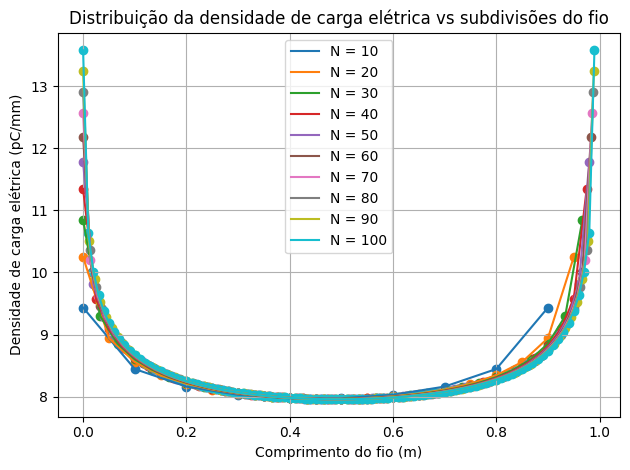

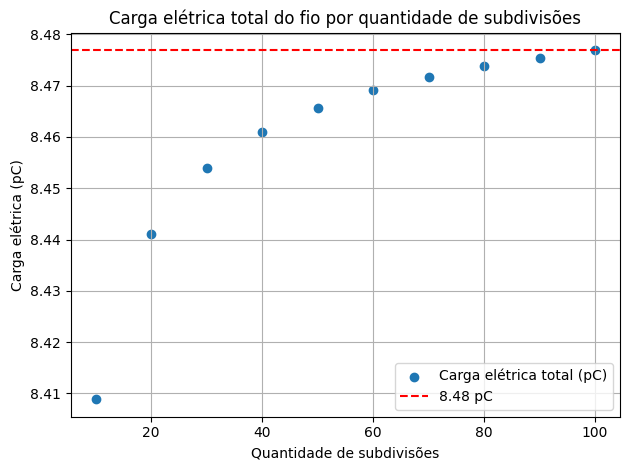

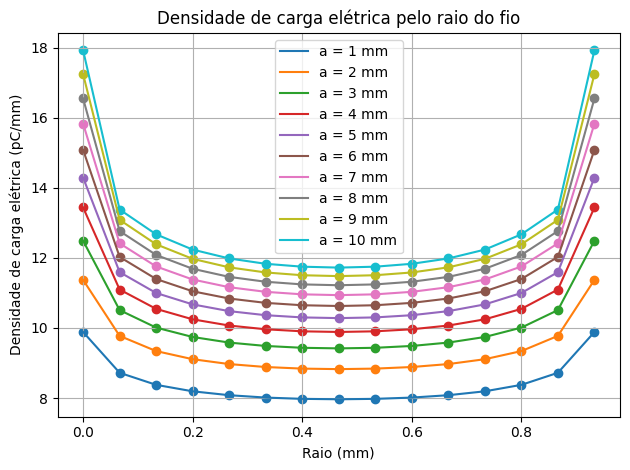

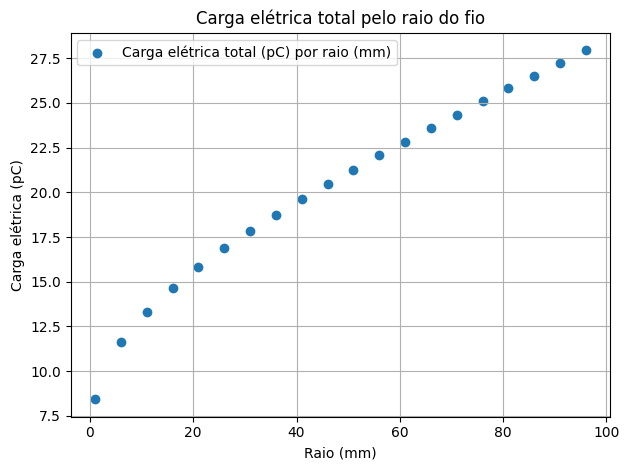

In [1]:
import math
import matplotlib.pyplot as plt

# ---------------- Funções de Álgebra Linear ----------------

def sistema_triangular_superior(A, b):
    n = len(b)
    x = [0.] * n
    for i in range(n - 1, -1, -1):
        soma = sum(A[i][j] * x[j] for j in range(i + 1, n))
        x[i] = (b[i] - soma) / A[i][i]
    return x

def sistema_triangular_inferior(A, b):
    n = len(b)
    x = [0.] * n
    for i in range(n):
        soma = sum(A[i][j] * x[j] for j in range(i))
        x[i] = (b[i] - soma) / A[i][i]
    return x

def fatoracao_lu(A):
    n = len(A)
    L = [[0.0]*n for _ in range(n)]
    U = [[0.0]*n for _ in range(n)]
    for i in range(n):
        for j in range(i, n):
            soma = sum(L[i][k] * U[k][j] for k in range(i))
            U[i][j] = A[i][j] - soma
        L[i][i] = 1
        for j in range(i + 1, n):
            soma = sum(L[j][k] * U[k][i] for k in range(i))
            L[j][i] = (A[j][i] - soma) / U[i][i]
    return L, U

# ---------------- Método dos Momentos ----------------

def metodo_dos_momentos(a, L, V0, N):
    epsilon0 = 8.854187817e-12
    deltax = L / N
    b = [4.0 * math.pi * epsilon0 * V0] * N
    Z = [[0.0]*N for _ in range(N)]

    for m in range(N):
        for n in range(N):
            x1    = 2.0 * (m - n) + 1
            x2    = 2.0 * (m - n) - 1
            delta = 2.0 * a / deltax
            Z[m][n] = math.log(abs((x1 + (x1**2 + delta**2)**0.5) /
                                   (x2 + (x2**2 + delta**2)**0.5)))

    L_mat, U_mat = fatoracao_lu(Z)
    y  = sistema_triangular_inferior(L_mat, b)
    q  = sistema_triangular_superior(U_mat, y)
    qn = [val / 1e-12 for val in q]  # pC/m

    V = [sum(Z[i][j] * q[j] / (4.0 * math.pi * epsilon0) for j in range(N))
         for i in range(N)]
    Q = sum(qn[i] * deltax for i in range(N))

    return qn, V, Q

# ---------------- Visualização ----------------

def plot_densidade_por_subdivisao(a, L, V0, inicioN, passoN, finalN):
    plt.title('Distribuição da densidade de carga elétrica vs subdivisões do fio')
    plt.xlabel('Comprimento do fio (m)')
    plt.ylabel('Densidade de carga elétrica (pC/mm)')
    plt.grid(True)

    for N in range(inicioN, finalN, passoN):
        deltax = L / N
        x = [i * deltax for i in range(N)]
        qn, _, _ = metodo_dos_momentos(a, L, V0, N)
        plt.plot(x, qn, label=f"N = {N}")
        plt.scatter(x, qn)

    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_carga_total_por_subdivisao(a, L, V0, inicioN, passoN, finalN):
    dx, Q0 = [], []

    for N in range(inicioN, finalN, passoN):
        qn, V, Q = metodo_dos_momentos(a, L, V0, N)
        dx.append(N)
        Q0.append(Q)

    plt.title('Carga elétrica total do fio por quantidade de subdivisões')
    plt.xlabel('Quantidade de subdivisões')
    plt.ylabel('Carga elétrica (pC)')
    plt.grid(True)
    plt.scatter(dx, Q0)
    plt.axhline(Q0[-1], color='r', linestyle='--')
    plt.legend(['Carga elétrica total (pC)', f"{Q0[-1]:.2f} pC"])
    plt.tight_layout()
    plt.show()

def plot_densidade_por_raio(L, V0, N, inicioa, passoa, finala):
    plt.title('Densidade de carga elétrica pelo raio do fio')
    plt.xlabel('Raio (mm)')
    plt.ylabel('Densidade de carga elétrica (pC/mm)')
    plt.grid(True)
    deltax = L / N
    x = [i * deltax for i in range(N)]

    for A in range(inicioa, finala, passoa):
        a = A / 1000
        qn, _, _ = metodo_dos_momentos(a, L, V0, N)
        plt.plot(x, qn, label=f"a = {A} mm")
        plt.scatter(x, qn)

    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_carga_total_por_raio(L, V0, N, inicioa, passoa, finala):
    Q0a, dxa = [], []
    for A in range(inicioa, finala, passoa):
        a = A / 1000
        qn, _, Q = metodo_dos_momentos(a, L, V0, N)
        dxa.append(A)
        Q0a.append(Q)

    plt.title('Carga elétrica total pelo raio do fio')
    plt.xlabel('Raio (mm)')
    plt.ylabel('Carga elétrica (pC)')
    plt.grid(True)
    plt.scatter(dxa, Q0a)
    plt.legend(['Carga elétrica total (pC) por raio (mm)'])
    plt.tight_layout()
    plt.show()

# ---------------- Execução ----------------

a  = 0.001  # Raio em metros
L  = 1.0    # Comprimento do fio (m)
V0 = 1.0    # Potencial (V)

plot_densidade_por_subdivisao(a, L, V0, inicioN=10, passoN=10, finalN=110)
plot_carga_total_por_subdivisao(a, L, V0, inicioN=10, passoN=10, finalN=110)
plot_densidade_por_raio(L, V0, N=15, inicioa=1, passoa=1, finala=11)
plot_carga_total_por_raio(L, V0, N=15, inicioa=1, passoa=5, finala=101)
